# Notebook Transformers

Este notebook crea un **mini GPT (decoder-only)** desde cero, siguiendo los siguientes pasos: 

- Construye un **tokenizador a nivel de carácter** para evitar dependencias externas.
- Implementa **Positional Encoding** sinusoidal 
- Programa un **Scaled Dot-Product Attention** con **máscara causal** (autoregresión).
- Arma **Multi-Head Attention**, **Transformer Block** y un **mini GPT** funcional.
- Entrenar un **LM pequeño** (~200 pasos) en un corpus de juguete.
- **Genera texto** (greedy / top-k / nucleus top-p / temperature) y visualizar **mapas de atención**.

**Recordatorio de las slides**
- En Transformers, el contexto se construye con **self-attention**, no con recurrencia.
- La máscara causal impide “ver el futuro”, manteniendo la generación **autoregresiva**.
- El Positional Encoding devuelve al modelo la noción de **orden** que la auto-atención no tiene por sí sola.


### Reproducibilidad y dispositivo
- `set_seed(seed)` fija semillas para `numpy`, `random` y `torch`. En GPU puede haber fuentes de no-determinismo (cuDNN), por lo que para reproducibilidad estricta habría que añadir flags adicionales (a costa de rendimiento).
- `find_device()` detecta y usa GPU (CUDA) si está disponible, luego MPS (Apple Silicon) y finalmente CPU.

In [1]:
# ---------------------------
# Imports & utilidades básicas
# ---------------------------
import re
import math
import random
import time
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# ---------------------------
# Reproducibilidad y dispositivo
# ---------------------------

def set_seed(seed: int = 1234) -> None:
    """
    Fija semillas para reproducibilidad en numpy, random y torch.

    NOTAS:
    - La reproducibilidad *perfecta* en GPU puede requerir flags adicionales:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
      Esto puede ralentizar el entrenamiento.
    - En hardware distinto (o versiones distintas de CUDA/cuDNN) puede haber
      pequeñas desviaciones numéricas.

    Args:
        seed: entero con la semilla global.
    """
    random.seed(seed)          # Python RNG
    np.random.seed(seed)       # NumPy RNG
    torch.manual_seed(seed)    # CPU y (en parte) GPU

    # Si hay CUDA disponible, fijamos también la semilla de todos los dispositivos
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_device() -> torch.device:
    """
    Detecta el mejor 'device' disponible en orden de preferencia:
        1) CUDA (GPU NVIDIA)
        2) MPS (GPU Apple/Metal)
        3) CPU

    Devuelve:
        torch.device apropiado, según disponibilidad.

    Detalles:
    - torch.cuda.is_available() -> True si hay GPU NVIDIA visible.
    - torch.backends.mps.is_available() -> True si PyTorch con backend Metal está listo.
    - Si ninguno está disponible, usamos CPU (siempre disponible).
    """
    # Preferimos CUDA si existe
    if torch.cuda.is_available():
        return torch.device("cuda")

    # Soporte para Apple Silicon (MPS). getattr evita error en builds sin backend mps.
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")

    # Fallback universal
    return torch.device("cpu")


# Seleccionamos device y fijamos la semilla global por defecto
device = find_device()
print("DEVICE:", device)

SEED = 1234
set_seed(SEED)

DEVICE: mps


## 1) Corpus de juguete y tokenizador *char-level*

**¿Por qué char-level?**  
- Evitamos dependencias externas (BPE/WordPiece/SentencePiece) y reducimos complejidad como ejemplo.   
- No existe el problema **OOV** (Out-Of-Vocabulary): cualquier carácter visto entra al vocabulario.  
- Desventaja: las secuencias son más largas y la semántica por token es más “débil” que con subpalabras.

**Preprocesamiento elegido (simple):**  
- `strip()` para limpiar saltos/espacios de los extremos.  
- `lower()` para evitar duplicar vocabulario por mayúsculas/minúsculas.

**Vocabulario y mapeos:**  
- `chars`: conjunto ordenado de caracteres presentes en el corpus.  
- `stoi` (*string-to-index*): dict que asigna **cada carácter** → **un id** `[0..V-1]`.  
- `itos` (*index-to-string*): inverso de `stoi`, para decodificar ids → texto.

**Tarea LM (lenguaje autoregresivo):**  
- Dado un bloque de `T` caracteres (contexto), el modelo predice el **siguiente** carácter en cada posición.  
- Construimos pares `(X, Y)` desfasados: `Y` es `X` desplazado 1 paso a la derecha.

**Hiperparámetros clave:**  
- `block_size`: longitud del **contexto** (ventana deslizante).  
- `step`: stride del *sliding window* (por defecto 1, máxima densidad de ejemplos).

**Split de datos:**  
- Usamos 90% para *train* y 10% para *val*, manteniendo la distribución del corpus (simple y suficiente para clase).


In [2]:
# -----------------------------------------
# Corpus de juguete y tokenizador char-level
# -----------------------------------------

# 1) Texto base (corpus)
#    - Usamos un párrafo corto y autocontenido.
#    - lower(): reducimos el tamaño del vocabulario (no distinguimos mayúsculas/minúsculas).
#    - strip(): remove espacios/saltos iniciales y finales que podrían contaminar el conteo.
corpus = (
    '\nonce upon a time there was a tiny transformer.\n'
    'it liked attending to tokens and making predictions.\n'
    'sometimes it was right. sometimes it was wrong.\n'
    'but it always tried to learn from its mistakes.\n'
    'transformers are attention machines.\n'
).strip().lower()

print("Corpus length (chars):", len(corpus))
print("Sample:", corpus[:120])  # vistazo rápido para confirmar preprocesamiento


# 2) Vocabulario de caracteres
#    - Extraemos caracteres únicos y los ordenamos para tener un índice estable.
#    - Esto garantiza que el mapping no dependa del orden de aparición en el texto.
chars = sorted(list(set(corpus)))

# stoi: string-to-index
#  - Mapea cada carácter del vocabulario a un entero único.
# itos: index-to-string
#  - Inverso de stoi, útil para decodificar secuencias de ids a texto legible.
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)

print("Vocab size:", vocab_size)

# 3) Funciones de codificación/decodificación
def encode(s: str) -> list[int]:
    """
    Convierte una cadena en una lista de ids (uno por carácter).
    Nota: Si 's' contiene un carácter no visto en el vocabulario, lanzará KeyError.
          Como el vocab es del propio corpus, en este notebook no habrá OOV.
    """
    return [stoi[c] for c in s]

def decode(ids: list[int]) -> str:
    """
    Convierte una lista de ids en la cadena correspondiente.
    """
    return ''.join(itos[i] for i in ids)

# Sanity check: codificar/decodificar una palabra
print("| Example ids for 'transformers ':", encode("transformers "))


# 4) Dataset para lenguaje autoregresivo (LM)
def make_dataset(text: str, block_size: int = 64, step: int = 1):
    """
    Genera pares (X, Y) para entrenamiento de un Language Model autoregresivo.

    Args:
        text: texto completo del cual extraer secuencias.
        block_size: longitud del contexto (ventana) en caracteres. Cada X tiene shape [block_size].
        step: stride del *sliding window*. Con step=1 generamos el máximo número de ejemplos
              (ventana que avanza de a 1 char). Aumentar step reduce ejemplos y costo.

    Returns:
        X: Tensor Long de shape [N, block_size]
        Y: Tensor Long de shape [N, block_size]
           donde Y[j] = X[j] pero desplazado 1 posición a la derecha,
           es decir, Y[t] es el "siguiente carácter" del X[t].

    Detalles:
        - Para una secuencia data = [c0, c1, ..., c_{T-1}], un bloque (X) es [c_i ... c_{i+block_size-1}]
          y su objetivo (Y) es [c_{i+1} ... c_{i+block_size}], así el modelo aprende a predecir c_{t+1}.
        - dtype=torch.long es importante porque los embeddings esperan índices enteros.
    """
    # Convertimos todo el texto a ids una sola vez
    data = torch.tensor(encode(text), dtype=torch.long)

    X, Y = [], []
    # i recorre el corpus abriendo ventanas de block_size.
    # Nos detenemos en len(data) - block_size - 1 para que Y tenga la posición +1 válida.
    for i in range(0, len(data) - block_size - 1, step):
        x = data[i : i + block_size]           # contexto
        y = data[i + 1 : i + block_size + 1]   # mismo contexto corrido 1 (próximo char)
        X.append(x)
        Y.append(y)

    # Apilamos listas a tensores [N, block_size]
    return torch.stack(X), torch.stack(Y)


# 5) Construimos el dataset con una ventana de 64
block_size = 64
X, Y = make_dataset(corpus, block_size=block_size, step=1)
print("Dataset shapes -> X:", X.shape, "| Y:", Y.shape)
# Interpretación:
#   - X.shape = [N, 64], Y.shape = [N, 64]
#   - Para cada fila j y cada columna t, el modelo verá X[j, t] y deberá predecir Y[j, t] = siguiente char.


# 6) Split Train/Val (secuencial simple)
#    - Tomamos 90% para entrenamiento y 10% para validación.
#    - Como los ejemplos se generan con ventana deslizante, la distribución se mantiene.
n = int(0.9 * len(X))
Xtr, Ytr = X[:n], Y[:n]
Xval, Yval = X[n:], Y[n:]

print("Train size:", len(Xtr), "| Val size:", len(Xval))


Corpus length (chars): 232
Sample: once upon a time there was a tiny transformer.
it liked attending to tokens and making predictions.
sometimes it was rig
Vocab size: 24
| Example ids for 'transformers ': [20, 18, 3, 15, 19, 8, 16, 18, 14, 7, 18, 19, 1]
Dataset shapes -> X: torch.Size([167, 64]) | Y: torch.Size([167, 64])
Train size: 150 | Val size: 17


## 2) Positional Encoding (sinusoidal)

**Problema:** la *self-attention* por sí sola es **invariante al orden**; si permutamos los tokens, la operación no puede distinguir posiciones.  
**Solución:** sumamos a cada embedding un **vector posicional** que codifica la **posición absoluta** (y de manera indirecta, distancias relativas).

**Idea (Vaswani et al., 2017):** usar senos y cosenos con **frecuencias log-espaciadas** por dimensión:
- Para una posición `pos` y dimensión `2i` (par):  
  $$PE_{(pos,\,2i)} = \sin\left( \frac{pos}{10000^{2i/d}} \right)$$
- Para dimensión `2i+1` (impar):  
  $$PE_{(pos,\,2i+1)} = \cos\left( \frac{pos}{10000^{2i/d}} \right)$$

**Propiedades útiles:**
- No añade parámetros (eficiente).
- Permite **extrapolar** a longitudes mayores (por la estructura sinusoidal).
- Las diferencias de fase codifican **distancias relativas**: posiciones cercanas tienen representaciones similares.
- Se **suma** al embedding del token antes de entrar a la primera capa del Transformer.

> En práctica, algunos modelos usan **posicionales aprendidos** (embeddings), pero el sinusoidal es excelente como ejemplo: simple, interpretable y reproducible.


In [3]:
class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal (Vaswani et al., 2017).

    Construye una matriz 'pe' de shape [1, max_len, d_model] donde cada fila
    PE[pos] es un vector que codifica la posición 'pos' usando senos/cosenos
    de frecuencias log-espaciadas. Luego, en forward, se S U M A al embedding.

    Args:
        d_model: dimensión del embedding del token.
        max_len: longitud máxima de secuencia que soportaremos.

    Notas:
    - No tiene parámetros entrenables (usa register_buffer para que 'pe' viva en el modelo
      y se mueva de device correctamente, pero no aparezca en .parameters()).
    - Se asume que el input x viene como [B, T, C] (batch, time, channels=d_model).
    """

    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        # Creamos la tabla posicional
        pe = torch.zeros(max_len, d_model)               # [max_len, d_model]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]

        # div_term define las frecuencias por dimensión (pares e impares)
        # escaladas por 1/10000^(2i/d_model) según el paper.
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Asignamos sin a las dimensiones pares (0,2,4,...) y cos a las impares (1,3,5,...)
        pe[:, 0::2] = torch.sin(position * div_term)     # pares
        pe[:, 1::2] = torch.cos(position * div_term)     # impares

        # Añadimos batch-dim al frente para facilitar broadcasting: [1, max_len, d_model]
        pe = pe.unsqueeze(0)

        # Guardamos como buffer (no-entrenable, pero migra de device con el módulo)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Suma la codificación posicional a los embeddings de entrada.

        Args:
            x: Tensor [B, T, C] — típicamente salida de nn.Embedding.

        Returns:
            x + pe[:,:T] con la misma shape [B, T, C].
        """
        T = x.size(1)               # longitud de la secuencia
        # Broadcasting: [B, T, C] + [1, T, C] -> [B, T, C]
        return x + self.pe[:, :T, :]


## 3) Scaled Dot-Product Attention (con máscara causal)

**Objetivo:** dada una **query** (lo que “buscamos”), comparar con todas las **keys** (lo que “tenemos”) para obtener pesos de atención y hacer un **promedio ponderado** de las **values** (la información relevante).

**Fórmula base:**
1. *Scores* (similitud):  
    $$S = \frac{Q K^\top}{\sqrt{d_k}}$$
   Escalamos por $\sqrt{d_k}$ para mantener los gradientes estables.

2. *Máscara causal* (opcional):  
   - En modelos **autoregresivos** (GPT), posición `t` **no** puede atender a `t+1..T`.  
   - Se enmascara el triángulo superior con $-\infty$ para que `softmax` lo haga 0.

3. *Pesos de atención*:  
   $$A = \text{softmax}(S)$$

4. *Salida*:  
    $$\text{Attn}(Q,K,V) = A\,V$$

**Shapes (multi-head):**  
- `Q, K, V`: `[B, h, T, d_h]` → batch, número de cabezas, secuencia, dimensión por cabeza.  
- Salida: `[B, h, T, d_h]` (luego se concatena por cabezas).

In [4]:
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    causal_mask: bool = False
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Scaled Dot-Product Attention con opción de máscara causal.

    Args:
        Q: Queries  [B, h, T_q, d_h]
        K: Keys     [B, h, T_k, d_h]
        V: Values   [B, h, T_k, d_h]
        causal_mask: si True, enmascara posiciones futuras (autoregresivo).

    Returns:
        out: salida atencional [B, h, T_q, d_h]
        A:   pesos de atención (softmax) [B, h, T_q, T_k]

    Detalles:
    - Scores = (Q @ K^T) / sqrt(d_h)
    - Si causal_mask: anulamos scores por encima de la diagonal con -inf para que softmax -> 0.
    - A = softmax(scores) sobre la dimensión de keys.
    - out = A @ V  (promedio ponderado de V).
    """
    # 1) Similitud escalada
    d_k = Q.size(-1)  # d_h (dimensión por cabeza)
    # [B, h, T_q, T_k]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # 2) Máscara causal (solo válida cuando T_q == T_k y queremos no mirar el futuro)
    if causal_mask:
        T_k = scores.size(-1)
        # Triángulo superior (strictly above main diagonal) -> True para enmascarar
        mask = torch.triu(torch.ones(T_k, T_k, device=scores.device), diagonal=1).bool()
        # Expandimos el mask si T_q==T_k; en práctica usual del decoder self-attention lo es.
        scores = scores.masked_fill(mask, float('-inf'))

    # 3) Softmax -> pesos de atención (cada fila suma 1)
    A = torch.softmax(scores, dim=-1)  # [B, h, T_q, T_k]

    # 4) Combinación ponderada de valores
    out = torch.matmul(A, V)           # [B, h, T_q, d_h]

    return out, A


## 4) Multi-Head Attention

**Motivación:** una única atención aprende **una sola “vista”** del patrón Q–K–V.  
Con **múltiples cabezas**, el modelo:
- Proyecta los embeddings a distintos **subespacios** (una por cabeza).
- Calcula atenciones **en paralelo** (una por cabeza).
- **Concatena** y mezcla de vuelta al espacio original con `W_o`.

**Flujo:**
1. Proyectar `x` (y `context` si hay **cross-attention**) a `Q, K, V` con `W_q, W_k, W_v`.
2. Partir en `num_heads` cabezas: shape `[B, h, T, d_h]` con `d_h = d_model / h`.
3. Llamar a **scaled dot-product attention** (con máscara causal si es **self-attn** autoregresiva).
4. Concatenar las cabezas y aplicar `W_o`.

**Self vs Cross attention:**
- **Self-attention** (`context=None`): `Q_in=K_in=V_in=x`.  
- **Cross-attention** (`context` no es `None`): `Q` viene del **decoder**, `K,V` del **encoder**.

**Notas prácticas:**
- Requisito: `d_model % num_heads == 0` (para `d_h` entero).  
- La máscara **causal** se aplica en **decoder self-attention** (no se mira el futuro).


In [5]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention que devuelve SIEMPRE (out, A).

    - Calcula proyecciones Q, K, V con capas lineales compartidas
      (equivalentes a conv 1x1 en la dimensión de canales).
    - Reorganiza a 'num_heads' cabezas de dimensión 'head_dim = d_model // num_heads'.
    - Llama a 'scaled_dot_product_attention' (con máscara causal si corresponde).
    - Concatena cabezas y proyecta con W_o al espacio original d_model.
    - Devuelve:
        out: Tensor [B, T_q, d_model]
        A:   Pesos de atención [B, h, T_q, T_k] (o None si no se generaron por alguna razón).

    Args:
        d_model (int): Dimensión del embedding/canales de entrada.
        num_heads (int): Número de cabezas de atención (h).
        causal (bool): Si True, aplica máscara causal SOLO en self-attention (autoregresivo).

    Notas:
    - Requisito: d_model % num_heads == 0 (para que head_dim sea entero).
    - En self-attention (decoder tipo GPT), T_q == T_k == T.
    - En cross-attention, T_q y T_k pueden diferir (p. ej., longitud del decoder vs encoder).
    """
    def __init__(self, d_model: int, num_heads: int, causal: bool):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Parámetros y dimensiones
        self.d_model   = d_model
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.causal    = causal

        # Proyecciones aprendibles (una por tipo); mapean d_model -> d_model
        # Se dividirán luego en 'num_heads' cabezas.
        self.Wq = nn.Linear(d_model, d_model, bias=False)  # Queries
        self.Wk = nn.Linear(d_model, d_model, bias=False)  # Keys
        self.Wv = nn.Linear(d_model, d_model, bias=False)  # Values

        # Proyección de salida que mezcla las cabezas concatenadas
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor, context: torch.Tensor | None = None):
        """
        Forward de MHA.

        Args:
            x:       [B, T_q, d_model]  Secuencia de entrada (queries).
            context: [B, T_k, d_model]  Secuencia fuente (keys/values) en cross-attention.
                     Si None => self-attention (Q=K=V=x).

        Returns:
            out: [B, T_q, d_model]  Representaciones mezcladas de todas las cabezas.
            A:   [B, h, T_q, T_k]   Pesos de atención (o None si no se calcularon).
        """
        # 1) Selección de origen de Q, K, V
        if context is None:
            # Self-attention: la misma secuencia genera Q, K, V.
            Q_in = K_in = V_in = x
        else:
            # Cross-attention: Q desde x (p.ej., decoder), K y V desde context (p.ej., encoder).
            Q_in = x
            K_in = context
            V_in = context

        # 2) Dimensiones base
        B, T_q, C = Q_in.shape           # batch, tiempo de queries, canales=d_model
        T_k = K_in.shape[1]              # tiempo de keys/values (puede diferir en cross-attn)

        # 3) Proyecciones y partición en cabezas
        #    [B, T, d_model] --Wq--> [B, T, d_model] --reshape--> [B, T, h, d_h] --transpose--> [B, h, T, d_h]
        Q = self.Wq(Q_in).view(B, T_q, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.Wk(K_in).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.Wv(V_in).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)

        # 4) Atención (con máscara causal SOLO si es self-attn)
        #    La función devuelve 'out' y 'A'. En caso de redefiniciones accidentales
        #    que cambien la firma, protegemos el desempaquetado.
        attn_ret = scaled_dot_product_attention(
            Q, K, V,
            causal_mask=self.causal and (context is None)
        )

        if isinstance(attn_ret, tuple) and len(attn_ret) == 2:
            out_heads, A = attn_ret          # out_heads: [B, h, T_q, d_h]
        else:
            out_heads, A = attn_ret, None    # tolera implementación que no devuelva A

        # 5) Reunir cabezas: [B, h, T_q, d_h] -> [B, T_q, h*d_h(=d_model)]
        out = out_heads.transpose(1, 2).contiguous().view(B, T_q, C)

        # 6) Proyección final al espacio d_model
        out = self.Wo(out)                   # [B, T_q, d_model]

        return out, A




## 5) Bloque Transformer (decoder)

Un bloque de **decoder** (tipo GPT) combina:
1. **(LayerNorm) → Multi-Head Self-Attention (+ residual)**  
2. **(LayerNorm) → Feed-Forward posición-a-posición (+ residual)**

**Detalles clave:**
- **Pre-LayerNorm** (aplicamos `LayerNorm` ANTES de cada subcapa): mejora estabilidad del entrenamiento en práctica.
- **Conexiones residuales**: facilitan el flujo del gradiente (evitan desvanecimiento).
- **Feed-Forward**: MLP por posición (misma red para cada token de la secuencia), suele escalar `d_ff ≈ 4 * d_model`.
- En un **decoder autoregresivo**, la self-attention usa **máscara causal** (se definió en el módulo de atención).

> En encoder–decoder clásicos, el bloque del decoder también incluye una subcapa de **cross-attention**.
> Aquí construimos el bloque **decoder-only** (estilo GPT) para un LM autoregresivo.


In [6]:
class FeedForward(nn.Module):
    """
    MLP posición-a-posición:
        d_model -> d_ff -> d_model
    Se aplica independientemente a cada posición (misma red para todo T).

    Args:
        d_model: dimensión del embedding.
        d_ff:   dimensión intermedia (suele ser 4*d_model).
        dropout: regularización ligera tras la segunda proyección.
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),                # activación suave (también se usa ReLU; GELU es común en Transformers)
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class TransformerBlock(nn.Module):
    """
    Bloque Transformer (decoder-only, estilo GPT) con esquema **pre-LayerNorm**.

    Estructura (pre-LN):
        x -----> LN ----> Multi-Head Self-Attention ----> + (residual) ----> *
         * ----> LN ------------------> FeedForward -----> + (residual) ----> salida

    Características:
    - **Pre-LN**: aplicamos LayerNorm ANTES de cada subcapa. Suele mejorar estabilidad
      del entrenamiento y permite usar modelos más profundos sin colapsos de gradiente.
    - **Residuals**: conexiones residuales en ambas subcapas (attn y MLP) para facilitar
      el flujo del gradiente.
    - **Self-Attention causal**: la máscara causal se decide dentro de `MultiHeadAttention`
      cuando `context is None`. Si pasas `context`, actúa como **cross-attention**.
    - **Tolerancia a A=None**: por robustez del cuaderno docente, permitimos que
      `MultiHeadAttention` pueda no devolver mapas de atención (A) sin romper el forward.

    Args:
        d_model (int): dimensión del embedding / canales del bloque.
        num_heads (int): número de cabezas en la MHA.
        d_ff (int): dimensión intermedia del MLP posición-a-posición (típicamente ~4*d_model).
        causal (bool): si True, usa máscara causal en self-attention (autoregresivo).

    forward:
        x (Tensor): [B, T, d_model] entradas (embeddings + PE).
        context (Tensor | None): si se provee, K/V vendrán de `context` (cross-attention).
        return_attn (bool): si True, retorna también los pesos A (o None si no disponibles).

    Returns:
        - si return_attn=False: Tensor [B, T, d_model]
        - si return_attn=True : (Tensor [B, T, d_model], A [B, h, T_q, T_k] | None)
    """
    def __init__(self, d_model: int, num_heads: int, d_ff: int, causal: bool):
        super().__init__()

        # Subcapa 1: Multi-Head Attention (self o cross, según 'context')
        self.attn = MultiHeadAttention(d_model, num_heads, causal=causal)
        self.ln1  = nn.LayerNorm(d_model)   # pre-norm antes de MHA

        # Subcapa 2: MLP posición-a-posición (misma red para todas las posiciones)
        self.ff   = FeedForward(d_model, d_ff)
        self.ln2  = nn.LayerNorm(d_model)   # pre-norm antes del MLP

    def forward(
        self,
        x: torch.Tensor,
        context: torch.Tensor | None = None,
        return_attn: bool = False
    ):
        # ---------- Subcapa 1: (Pre-LN) -> Atención -> Residual ----------
        # Normalizamos primero (pre-LN) para estabilizar activaciones y gradientes
        x_norm = self.ln1(x)                       # [B, T, d_model]

        # Atención multi-cabeza:
        # - Si context is None -> self-attention causal (GPT).
        # - Si context no es None -> cross-attention (Q de x_norm, K/V de context).
        attn_out, A = self.attn(x_norm, context=context)   # attn_out: [B, T, d_model]

        # Conexión residual: sumamos la salida de attn a la rama original
        x = x + attn_out

        # ---------- Subcapa 2: (Pre-LN) -> FeedForward -> Residual ----------
        x_norm2 = self.ln2(x)                      # [B, T, d_model]
        ff_out  = self.ff(x_norm2)                 # [B, T, d_model]
        x       = x + ff_out                       # residual

        # Devolvemos los mapas de atención si se solicitaron; A puede ser None
        if return_attn:
            return x, A
        return x




## 6) Mini GPT (decoder-only)

**Qué construimos:** un **LM autoregresivo** estilo GPT (solo *decoder*) con:
1) **Embedding** de tokens (char-level).
2) **Positional Encoding** sinusoidal sumado al embedding.
3) `N` capas **TransformerBlock** (self-attention causal + MLP posición-a-posición).
4) **LayerNorm final** + **capa lineal** para proyectar a vocabulario y obtener logits.

**Por qué “decoder-only”:**
- En GPT, cada posición solo puede atender al **pasado** (máscara causal).
- No hay cross-attention a un encoder: el modelo aprende directamente a **predecir el siguiente token**.

**Salida del `forward`:**
- `logits`: tensor `[B, T, V]` con puntajes por token del vocabulario en cada posición.
- `A_last`: mapas de atención de la **última capa**, útiles para **visualización didáctica**.



In [7]:
# -------------------------------
# 6) Mini GPT (decoder-only)
# -------------------------------
class TinyGPT(nn.Module):
    """
    Un pequeño modelo GPT (solo-decoder) para LM char-level.

    Arquitectura:
      tokens -> Embedding (d_model)
             -> + PositionalEncoding (d_model)
             -> [TransformerBlock(...)] * num_layers   # self-attn causal + MLP
             -> LayerNorm
             -> Linear(d_model -> vocab_size)          # logits por token

    Args:
        vocab_size: tamaño del vocabulario (caracteres únicos).
        d_model: dimensión del embedding y canales internos.
        num_layers: número de bloques Transformer.
        num_heads: cabezas en multi-head attention.
        d_ff: tamaño intermedio del MLP (típicamente ~ 4 * d_model).
        max_len: longitud máxima soportada por PE.
        dropout: regularización ligera en el MLP.
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        num_layers: int = 2,
        num_heads: int = 4,
        d_ff: int = 256,
        max_len: int = 512,
        dropout: float = 0.1
    ):
        super().__init__()
        # 1) Embedding de tokens
        self.tok_emb = nn.Embedding(vocab_size, d_model)

        # 2) Positional Encoding sinusoidal
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)

        # 3) Pila de bloques Transformer (self-attn causal)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, causal=True)
            for _ in range(num_layers)
        ])

        # 4) Normalización final + proyección a vocabulario
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx: torch.Tensor):
        """
        idx: [B, T] con ids de caracteres.

        Devuelve:
            logits: [B, T, V]  (sin softmax; se usa CrossEntropyLoss)
            A_last: mapas de atención [h, T, T] de la última capa (para visualización)
        """
        # Embedding + posiciones
        x = self.tok_emb(idx)            # [B, T, C=d_model]
        x = self.pos_enc(x)              # suma PE: mantiene shape [B, T, C]

        A_last = None
        # Recorremos bloques; del último devolvemos atención para visualización
        for i, block in enumerate(self.blocks):
            last = (i == len(self.blocks) - 1)
            if last:
                x, A_last = block(x, return_attn=True)
            else:
                x = block(x)

        # Norm final + proyección a vocabulario
        x = self.ln_f(x)
        logits = self.head(x)            # [B, T, V]

        return logits, A_last


# Instanciamos el modelo (se asume que ya tienes 'vocab_size', 'block_size' y 'device' definidos)
model = TinyGPT(
    vocab_size=vocab_size,
    d_model=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    max_len=block_size
).to(device) 

# Cantidad de parámetros (útil para dimensionar la demo)
sum_params = sum(p.numel() for p in model.parameters())
print("Model params:", sum_params)


Model params: 270336


## 7) Entrenamiento (200 pasos, amigable con maquinas pequeñas, para correr local)

**Bucle de entrenamiento** (LM autoregresivo):
- Minibatch `(xb, yb)` con shape `[B, T]`.
- `logits = model(xb)` → `[B, T, V]`.
- `CrossEntropy` sobre `logits.view(-1, V)` vs `yb.view(-1)` (uno por posición).
- `AdamW` con `lr=3e-4` (estable para demos).
- `estimate_loss` evalúa rápido en *val* con `model.eval()` y `no_grad()`.

**Tips para MPS/CUDA:**
- Mueve tensores a `device` solo una vez y reutiliza (`Xtr_d`, `Ytr_d`, …).
- Si la **memoria** se aprieta, reduce `batch_size` o `d_model`.
- En MPS/CUDA, no necesitas `pin_memory=True`. Si deseas, puedes llamar a `torch.mps.empty_cache()` al terminar.


In [8]:
# ---------------------------------
# 7) Entrenamiento (200 pasos)
# ---------------------------------

def get_batch(X: torch.Tensor, Y: torch.Tensor, batch_size: int = 32):
    """
    Samplea un minibatch aleatorio de pares (X, Y).

    Args:
        X, Y: tensores en device (MPS en tu caso) con shape [N, T]
        batch_size: tamaño de lote

    Returns:
        xb, yb: tensores [B, T] en el mismo device
    """
    ix = torch.randint(0, X.shape[0], (batch_size,), device=X.device)
    xb = X[ix]
    yb = Y[ix]
    return xb, yb


def estimate_loss(model: nn.Module, X: torch.Tensor, Y: torch.Tensor, iters: int = 10) -> float:
    """
    Estima la pérdida media en un subconjunto de minibatches de validación.

    - Usa eval() + no_grad() para desactivar dropout y gradientes.
    - Mantiene el modelo en el device actual (MPS).
    """
    model.eval()
    losses = []
    with torch.no_grad():
        for _ in range(iters):
            xb, yb = get_batch(X, Y, batch_size=32)
            logits, _ = model(xb)  # logits: [B, T, V]
            # CrossEntropy espera [N, V] y targets [N]
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), yb.view(-1))
            losses.append(loss.item())
    model.train()
    return float(sum(losses) / len(losses))


# Optimizador (AdamW es estándar en Transformers)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Pasos de entrenamiento y logging
max_steps = 200      # pequeño para clase / CPU/MPS
log_every = 50       # imprime cada 50 pasos

# Subir dataset al device UNA sola vez (MPS)
Xtr_d, Ytr_d = Xtr.to(device), Ytr.to(device)
Xval_d, Yval_d = Xval.to(device), Yval.to(device)

for step in range(1, max_steps + 1):
    # 1) Batch
    xb, yb = get_batch(Xtr_d, Ytr_d, batch_size=32)

    # 2) Forward
    logits, _ = model(xb)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), yb.view(-1))

    # 3) Backward + Update
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # 4) Logging periódico + validación rápida
    if step % log_every == 0 or step == 1:
        train_loss = loss.item()
        val_loss = estimate_loss(model, Xval_d, Yval_d, iters=10)
        print(f"step {step:4d} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f}")

# (Opcional) Liberar caché de MPS al terminar largos entrenamientos:
# import torch.mps as mps
# mps.empty_cache()


step    1 | train_loss 3.440 | val_loss 3.413
step   50 | train_loss 1.764 | val_loss 2.400
step  100 | train_loss 1.193 | val_loss 2.436
step  150 | train_loss 0.516 | val_loss 2.579
step  200 | train_loss 0.225 | val_loss 2.336


## 8) Generación (greedy / top-k / top-p / temperature)

Dado un texto inicial (*prompt*), el modelo **autoregresivo** predice repetidamente el **siguiente token** y lo concatena a la secuencia.

**Detalles importantes:**
- **Contexto**: en cada paso alimentamos al modelo con el último `block_size` de tokens (ventana fija).
- **Logits → probabilidades**: aplicamos `softmax` a los logits de la **última posición** (`[:, -1, :]`) y muestreamos el siguiente id.
- **Temperature**: escala los logits antes del softmax.
  - >1.0 → distribuciones **más planas** (más aleatorio).
  - <1.0 → distribuciones **más picudas** (más determinista).
  - ~0 → aproxima **greedy** (elige el máximo).
- **Top-k**: restringe la muesta a los `k` tokens **más probables** (pone 0 al resto y renormaliza).
- **Top-p (nucleus)**: ordena por probabilidad, acumula hasta superar `p` y **recorta dinámicamente**.
- **Greedy**: si quieres greedy puro, puedes fijar `temperature≈0` o reemplazar la muesta por `argmax`.

**Notas prácticas (clase / MPS):**
- Asegúrate de construir el tensor de entrada en el **mismo device** del modelo.
- Para reproducibilidad, fija `torch.manual_seed` antes de generar.
- Con prompts muy cortos, el estilo puede ser más “ruidoso”; aumentar `top_k` o bajar `temperature` puede ayudar.


In [9]:
@torch.no_grad()
def generate(
    model: nn.Module,
    start_text: str = "transformers ",
    max_new_tokens: int = 120,
    top_k: int | None = None,
    top_p: float | None = None,
    temperature: float = 1.0
) -> str:
    """
    Genera texto autoregresivamente a partir de un prompt.

    Args:
        model: modelo autoregresivo (TinyGPT).
        start_text: prompt inicial (cadena).
        max_new_tokens: cuántos tokens nuevos generar.
        top_k: si no es None, muestrea solo entre los k tokens más probables.
        top_p: si no es None, nucleus sampling (probabilidad acumulada <= p).
        temperature: escala los logits antes del softmax (controla aleatoriedad).

    Returns:
        Cadena con el texto generado (prompt + nuevos tokens).
    """
    model.eval()  # desactiva dropout, etc.

    # 1) Codificamos el prompt y lo subimos al device del modelo
    idx = torch.tensor([encode(start_text)], dtype=torch.long, device=device)  # [1, T0]

    for _ in range(max_new_tokens):
        # 2) Cortamos al último 'block_size' (ventana causal)
        #    y pedimos logits para cada posición; nos quedamos con la última.
        logits, _ = model(idx[:, -block_size:])      # [1, T, V]
        logits = logits[:, -1, :]                    # [1, V] -> última posición

        # 3) Temperature scaling (evitar división por 0)
        logits = logits / max(1e-6, temperature)

        # 4) Softmax -> distribución de probas sobre vocabulario
        probs = torch.softmax(logits, dim=-1)        # [1, V]

        # 5) Top-k (opcional): enmascara todo excepto los k más probables
        if top_k is not None:
            # Tomamos los k índices con mayor probabilidad
            v, ix = torch.topk(probs, top_k, dim=-1)
            mask = torch.ones_like(probs, dtype=torch.bool)
            mask.scatter_(1, ix, False)              # False = mantener; True = enmascarar
            probs = probs.masked_fill(mask, 0.0)
            probs = probs / probs.sum(dim=-1, keepdim=True)  # renormalizar

        # 6) Top-p / nucleus (opcional): recorte dinámico por masa acumulada
        if top_p is not None:
            sorted_probs, sorted_idx = torch.sort(probs, descending=True, dim=-1)
            cum = torch.cumsum(sorted_probs, dim=-1)
            mask = cum > top_p                       # True = fuera del núcleo
            mask[..., 0] = False                     # siempre permitir el más probable
            sorted_probs = sorted_probs.masked_fill(mask, 0.0)
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)

            # Muestreamos en el espacio ordenado y mapeamos a índices reales
            idx_next_sorted = torch.multinomial(sorted_probs, num_samples=1)  # [1,1]
            idx_next = sorted_idx.gather(-1, idx_next_sorted)                 # [1,1]
        else:
            # 7) Muestreo categórico estándar (si no hay top-p)
            idx_next = torch.multinomial(probs, num_samples=1)                # [1,1]

        # 8) Concatenamos el nuevo token a la secuencia y repetimos
        idx = torch.cat([idx, idx_next], dim=1)        # [1, T+1]

    # 9) Decodificamos ids -> texto
    return decode(idx[0].tolist())


# Ejemplo de uso: sampling con top-k y temperature suave
print(generate(model, start_text="transformers ", max_new_tokens=120, top_k=20, temperature=0.9))


transformers ict iorns.
t alired atins atakend anng preediong preditieng tprediedictons tons timatimes was rakesfrer.
but ig anst and


## 9) Visualización de atención

Para entender **qué mira** el modelo, recuperamos los **pesos de atención** `A` de la **última capa** y los dibujamos por **cabeza**.

**Interpretación del mapa (por cabeza):**
- Eje **Y** (filas) = **queries** (posición que “pregunta”).
- Eje **X** (columnas) = **keys** (posiciones a las que se presta atención).
- Un color más intenso indica **mayor peso** de atención.

**Notas:**
- En un **decoder autoregresivo** (máscara causal), el triángulo superior aparece **enmascarado** (sin atención).
- Con textos más largos, puedes truncar a `block_size` para no sobrecargar la figura.
- La atención puede concentrarse en **símbolos recientes**, **puntuación** o **repeticiones** típicas del corpus.


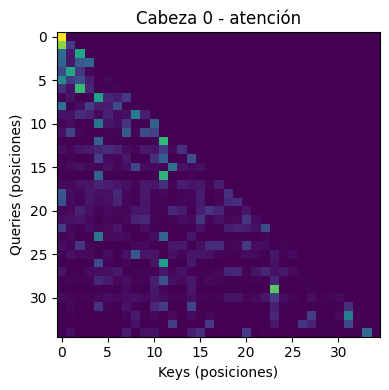

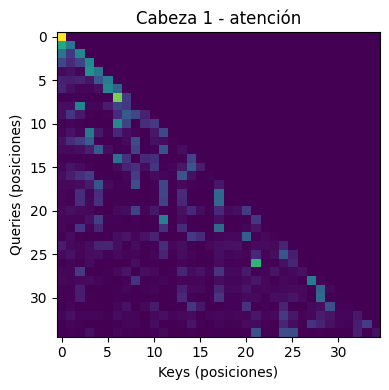

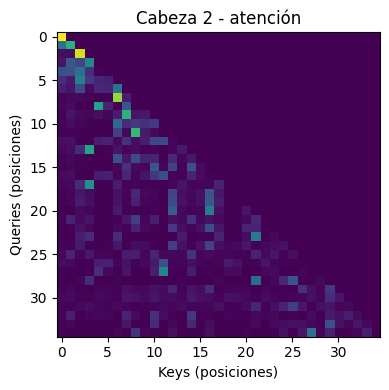

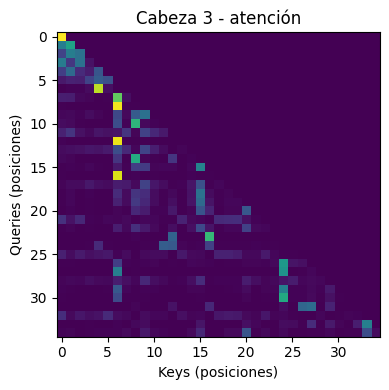

In [10]:
def plot_attention(model: nn.Module, text: str = "attention is all you need") -> None:
    """
    Dibuja los mapas de atención (por cabeza) de la **última capa** para un texto dado.

    Args:
        model: TinyGPT ya entrenado.
        text: cadena a codificar como entrada (se truncará a block_size si es más largo).

    Detalles:
        - Toma A desde la salida del forward del modelo (último bloque).
        - A tiene shape [heads, T, T] tras quitar batch-dim.
        - Dibuja una figura por cabeza.
    """
    model.eval()
    with torch.no_grad():
        # 1) Construimos input ids en el mismo device del modelo
        x = torch.tensor([encode(text)], dtype=torch.long, device=device)      # [1, T0]
        # 2) Cortamos a la ventana máxima
        logits, A = model(x[:, -block_size:])                                  # A: [h, T, T] (por nuestra implementación)
        # 3) Aseguramos CPU para matplotlib
        A = A[0].cpu().numpy()  # [heads, T, T]  (quitamos batch-dim; nuestra MHA ya devuelve [B,h,T,T])

        T = A.shape[-1]
        for h in range(A.shape[0]):
            plt.figure(figsize=(4, 4))
            plt.title(f"Cabeza {h} - atención")
            # Mapa: filas=queries, columnas=keys
            plt.imshow(A[h, :T, :T], aspect='auto')
            plt.xlabel("Keys (posiciones)")
            plt.ylabel("Queries (posiciones)")
            plt.tight_layout()
            plt.show()


# Ejemplo de uso
plot_attention(model, text="transformers are attention machines")


## 10) Ejercicios rápidos entregalos junto con tu tarea de transformers
1. Cambia `d_model` a 64 y repite entrenamiento. ¿Qué pasa con `val_loss`?
2. Cambia `num_heads` a 2 y visualiza atención. ¿Cómo cambian los patrones?
3. Prueba `top_k=None` y `top_p=0.9` en generación. Compara con `top_k=20`.
4. Reemplaza `corpus` por un texto de tu clase y observa el estilo de generación.
5. Quita (temporalmente) la máscara causal en `scaled_dot_product_attention` y observa cómo degenera la generación.

# Conclusión

En este notebook construimos un **mini GPT (decoder-only)** desde cero, paso a paso:

- Definimos un **tokenizador a nivel de caracteres**, evitando dependencias externas.
- Implementamos **Positional Encoding sinusoidal**, para inyectar información de orden en los embeddings.
- Construimos el núcleo del Transformer:
  - **Scaled Dot-Product Attention** con **máscara causal**.
  - **Multi-Head Attention** para capturar múltiples patrones en paralelo.
  - **Bloque Transformer** con normalización, residuals y MLP feed-forward.
- Juntamos todo en un **TinyGPT**, un modelo autoregresivo capaz de predecir el siguiente caracter.
- Entrenamos durante solo **200 pasos en CPU/MPS** para mostrar el ciclo de optimización.
- Probamos **generación de texto** con *greedy*, *temperature scaling*, *top-k* y *top-p* (nucleus).
- Finalmente, **visualizamos los mapas de atención** para entender en qué tokens se enfoca el modelo.


**Ideas clave:**
- La atención reemplaza a las RNN/CNN porque es **paralelizable** y puede modelar **dependencias largas**.
- El uso de *máscara causal* hace que el modelo sea **autoregresivo** (no ve el futuro).
- Técnicas de muestreo como *top-k* y *top-p* permiten controlar el balance entre **diversidad y coherencia**.
- Aunque este modelo es muy pequeño, los mismos bloques son la base de los **LLMs modernos** (GPT, LLaMA, PaLM, etc.).

✨ Este notebook sirve como una **mini ejemplo para enteder** a los grandes Transformers: todas las piezas están aquí, solo que en escala reducida.
